# 第二章
## 数据操作
张量（Tensor）：多维数组，深度学习的基本数据结构
n维数组，也称为张量（tensor）
具有一个轴的张量对应数学上的向量（vector）； 具有两个轴的张量对应数学上的矩阵（matrix）。
行（轴-0，形状的第一个元素） 和按列（轴-1，形状的第二个元素）。
在 Python 中，** 是幂运算符，用于计算一个数的幂次方。
常见操作：创建、索引、切片、运算
### 广播机制
1. 通过适当复制元素来扩展一个或两个数组，以便在转换之后，两个张量具有相同的形状；
2. 对生成的数组执行按元素操作。

第一个元素的索引是0，最后一个元素索引是-1；可以指定范围以包含第一个元素和最后一个之前的元素。

## 数据预处理
调用`read_csv`函数读取数据。

### 处理缺失值
“NaN”项代表缺失值。 为了处理缺失的数据，典型的方法包括插值法和删除法， 其中插值法用一个替代值弥补缺失值，而删除法则直接忽略缺失值。
缺失值处理：删除、填充
`pandas`可以与张量兼容

## 线性代数
张量可以具有任意长度，取决于机器的内存限制。向量的长度通常称为向量的维度（dimension）。代码矩阵的转置：A.T。
图像以n维数组形式出现， 其中3个轴对应于高度、宽度，以及一个通道（channel）轴， 用于表示颜色通道（红色、绿色和蓝色）。
以矩阵为例，为了通过求和所有行的元素来降维（轴0），可以在调用函数时指定axis=0。 由于输入矩阵沿0轴降维以生成输出向量，因此输入轴0的维数在输出形状中消失。指定axis=1将通过汇总所有列的元素降维（轴1）。因此，输入轴1的维数在输出形状中消失。
沿某个轴计算`A`元素的累积总和， 比如`axis=0`（按行计算），可以调用`cumsum`函数。 此函数不会沿任何轴降低输入张量的维度。
### 范数
向量的范数是表示一个向量有多大（分量的大小）。
第一个性质是：如果我们按常数因子α缩放向量的所有元素， 其范数也会按相同常数因子的绝对值缩放 𝑓(𝛼𝐱)=|𝛼|𝑓(𝐱).
第二个性质是熟悉的三角不等式 𝑓(𝐱+𝐲)≤𝑓(𝐱)+𝑓(𝐲).
第三个性质简单地说范数必须是非负的 𝑓(𝐱)≥0.
L1范数，它表示为向量元素的绝对值之和。

## 微积分
导数可以被解释为函数相对于其变量的瞬时变化率，它也是函数曲线的切线的斜率。
梯度是一个向量，其分量是多变量函数相对于其所有变量的偏导数。
链式法则可以用来微分复合函数。

## 自动微分
深度学习框架可以自动计算导数：首先将梯度附加到想要对其计算偏导数的变量上，然后记录目标值的计算，执行它的反向传播函数，并访问得到的梯度。

## 概率
### 边际化
为了能进行事件概率求和，我们需要求和法则（sum rule）， 即B的概率相当于计算A的所有可能选择，并将所有选择的联合概率聚合在一起：
P(B)=∑AP(A,B),
这也称为*边际化*（marginalization）。 边际化结果的概率或分布称为*边际概率*（marginal probability） 或*边际分布*（marginal distribution）。

In [1]:
import torch

# 创建张量
x = torch.tensor([1.0, 2, 3, 4])
y = torch.tensor([2.0, 2, 2, 2])

# 张量运算
x + y, x - y, x * y, x / y, x ** y  # **运算符是求幂运算 

(tensor([3., 4., 5., 6.]),
 tensor([-1.,  0.,  1.,  2.]),
 tensor([2., 4., 6., 8.]),
 tensor([0.5000, 1.0000, 1.5000, 2.0000]),
 tensor([ 1.,  4.,  9., 16.]))

In [2]:
# 广播机制
a = torch.arange(3).reshape(3, 1)
b = torch.arange(2).reshape(1, 2)
print(f"a = {a}")
print(f"b = {b}")
print(f"a + b = {a + b}")

a = tensor([[0],
        [1],
        [2]])
b = tensor([[0, 1]])
a + b = tensor([[0, 1],
        [1, 2],
        [2, 3]])


In [3]:
# 改变张量形状
A = torch.arange(12).reshape(3, 4)
B = torch.tensor([[2, 1, 4, 3], [1, 2, 3, 4], [4, 3, 2, 1]])
print(f"A.shape = {A.shape}")
print(f"A.reshape(4, 3) = {A.reshape(4, 3)}")
print(f"A.T = {A.T}")  # 转置

A.shape = torch.Size([3, 4])
A.reshape(4, 3) = tensor([[ 0,  1,  2],
        [ 3,  4,  5],
        [ 6,  7,  8],
        [ 9, 10, 11]])
A.T = tensor([[ 0,  4,  8],
        [ 1,  5,  9],
        [ 2,  6, 10],
        [ 3,  7, 11]])


In [4]:
# 张量索引和切片
print(f"A = {A}")
print(f"A[1] = {A[1]}")
print(f"A[1:3] = {A[1:3]}")
print(f"A[1, 2] = {A[1, 2]}")

A = tensor([[ 0,  1,  2,  3],
        [ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
A[1] = tensor([4, 5, 6, 7])
A[1:3] = tensor([[ 4,  5,  6,  7],
        [ 8,  9, 10, 11]])
A[1, 2] = 6


In [5]:
A_axis_1 = A.sum(axis=1)
A_axis_1

tensor([ 6, 22, 38])

In [6]:
# 矩阵运算
# 矩阵乘法
print(f"A.shape = {A.shape}, B.shape = {B.shape}")
print(f"A * B = {A * B}")  # 元素乘法
print(f"B.T = {B.T}")
print(f"torch.mm(A, B.T) = {torch.mm(A, B.T)}")  # 矩阵乘法

A.shape = torch.Size([3, 4]), B.shape = torch.Size([3, 4])
A * B = tensor([[ 0,  1,  8,  9],
        [ 4, 10, 18, 28],
        [32, 27, 20, 11]])
B.T = tensor([[2, 1, 4],
        [1, 2, 3],
        [4, 3, 2],
        [3, 4, 1]])
torch.mm(A, B.T) = tensor([[ 18,  20,  10],
        [ 58,  60,  50],
        [ 98, 100,  90]])


In [7]:
#读取数据集
import os

os.makedirs(os.path.join('..', 'data'), exist_ok=True)
data_file = os.path.join('..', 'data', 'house_tiny.csv')
with open(data_file, 'w') as f:
    f.write('NumRooms,Alley,Price\n')  # 列名
    f.write('NA,Pave,127500\n')  # 每行表示一个数据样本
    f.write('2,NA,106000\n')
    f.write('4,NA,178100\n')
    f.write('NA,NA,140000\n')

In [8]:
import pandas as pd

data = pd.read_csv(data_file)
print(data)

   NumRooms Alley   Price
0       NaN  Pave  127500
1       2.0   NaN  106000
2       4.0   NaN  178100
3       NaN   NaN  140000


In [9]:
#处理缺失值
inputs, outputs = data.iloc[:, 0:2], data.iloc[:, 2]
inputs = inputs.fillna(inputs.mean())
print(inputs)

   NumRooms Alley
0       3.0  Pave
1       2.0   NaN
2       4.0   NaN
3       3.0   NaN


In [10]:
inputs = pd.get_dummies(inputs, dummy_na=True)
print(inputs)

   NumRooms  Alley_Pave  Alley_nan
0       3.0           1          0
1       2.0           0          1
2       4.0           0          1
3       3.0           0          1


In [11]:
#转换为张量格式
import torch

X = torch.tensor(inputs.to_numpy(dtype=float))
y = torch.tensor(outputs.to_numpy(dtype=float))
X, y

(tensor([[3., 1., 0.],
         [2., 0., 1.],
         [4., 0., 1.],
         [3., 0., 1.]], dtype=torch.float64),
 tensor([127500., 106000., 178100., 140000.], dtype=torch.float64))

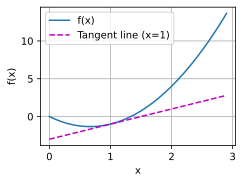

In [12]:
import numpy as np
from matplotlib_inline import backend_inline
from d2l import torch as d2l
def f(x):
    return 3 * x ** 2 - 4 * x
def use_svg_display():  
    """使用svg格式在Jupyter中显示绘图"""
    backend_inline.set_matplotlib_formats('svg')
def set_figsize(figsize=(3.5, 2.5)):  
    """设置matplotlib的图表大小"""
    use_svg_display()
    d2l.plt.rcParams['figure.figsize'] = figsize
def set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend):
    """设置matplotlib的轴"""
    axes.set_xlabel(xlabel)
    axes.set_ylabel(ylabel)
    axes.set_xscale(xscale)
    axes.set_yscale(yscale)
    axes.set_xlim(xlim)
    axes.set_ylim(ylim)
    if legend:
        axes.legend(legend)
    axes.grid()
def plot(X, Y=None, xlabel=None, ylabel=None, legend=None, xlim=None,
         ylim=None, xscale='linear', yscale='linear',
         fmts=('-', 'm--', 'g-.', 'r:'), figsize=(3.5, 2.5), axes=None):
    """绘制数据点"""
    if legend is None:
        legend = []

    set_figsize(figsize)
    axes = axes if axes else d2l.plt.gca()

    # 如果X有一个轴，输出True
    def has_one_axis(X):
        return (hasattr(X, "ndim") and X.ndim == 1 or isinstance(X, list)
                and not hasattr(X[0], "__len__"))

    if has_one_axis(X):
        X = [X]
    if Y is None:
        X, Y = [[]] * len(X), X
    elif has_one_axis(Y):
        Y = [Y]
    if len(X) != len(Y):
        X = X * len(Y)
    axes.cla()
    for x, y, fmt in zip(X, Y, fmts):
        if len(x):
            axes.plot(x, y, fmt)
        else:
            axes.plot(y, fmt)
    set_axes(axes, xlabel, ylabel, xlim, ylim, xscale, yscale, legend)

x = np.arange(0, 3, 0.1)
plot(x, [f(x), 2 * x - 3], 'x', 'f(x)', legend=['f(x)', 'Tangent line (x=1)'])

In [13]:
# 自动微分示例
x = torch.arange(4.0, requires_grad=True)
y = 2 * torch.dot(x, x)
y.backward()
print(f"x.grad = {x.grad}")

# 分离计算图
x.grad.zero_()
y = x.sum()
y.backward()
print(f"x.grad = {x.grad}")

x.grad.zero_()
y = x * x
y.sum().backward()
print(f"x.grad = {x.grad}")

x.grad = tensor([ 0.,  4.,  8., 12.])
x.grad = tensor([1., 1., 1., 1.])
x.grad = tensor([0., 2., 4., 6.])
